# Cement Manufacturing Dataset
## by HAMZAT ABDULRAHMAN

## Table of Contents


#### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from matplotlib import rcParams

%matplotlib inline

### Data Gathering

In [3]:
concrete = pd.read_csv("concrete.csv")
concrete.head(5)

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29


### Assessing

In [4]:
concrete.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


In [5]:
concrete.duplicated().sum()

25

In [6]:
concrete.describe()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [7]:
concrete.isna().sum()

cement          0
slag            0
ash             0
water           0
superplastic    0
coarseagg       0
fineagg         0
age             0
strength        0
dtype: int64

In [8]:
concrete['age'].isna().sum()

0

In [24]:
0 in concrete_clean['slag'].values

True

In [25]:
np.log10(concrete_clean['cement'].min())

2.0086001717619175

In [11]:
concrete.sample(5)

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
938,307.0,0.0,0.0,193.0,0.0,968.0,812.0,28,27.53
395,330.5,169.6,0.0,194.9,8.1,811.0,802.3,28,56.62
108,151.6,0.0,111.9,184.4,7.9,992.0,815.9,28,12.18
222,230.0,0.0,118.3,195.5,4.6,1029.4,758.6,100,35.34
201,159.8,250.0,0.0,168.4,12.2,1049.3,688.2,28,39.46


### Quality Issues:
1. There are 25 duplicate rows.

### Data Cleaning

In [12]:
# make a copy of dataframe
concrete_clean = concrete.copy()

#### Define:
Remove duplicated rows using `drop_duplicates()` function

#### code:

In [13]:
concrete_clean = concrete_clean.drop_duplicates()

#### Test

In [14]:
concrete_clean.duplicated().sum()

0

# Exploratory Analysis

## Univariate Exploration

#### Question:
How does the distribution of "strength" of concrete looks?

#### Visualization

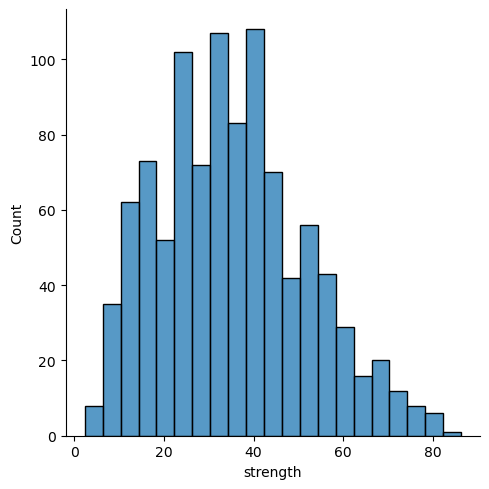

In [15]:
bin_edges = np.arange(concrete_clean['strength'].min(),concrete_clean['strength'].max() + 4, 4)
sb.displot(concrete_clean['strength'], bins = bin_edges);

#### Observation:
Approximately normal distribution with more than one peak

#### Question:
How does the distribution of "cement" of concrete looks?

#### Visualization

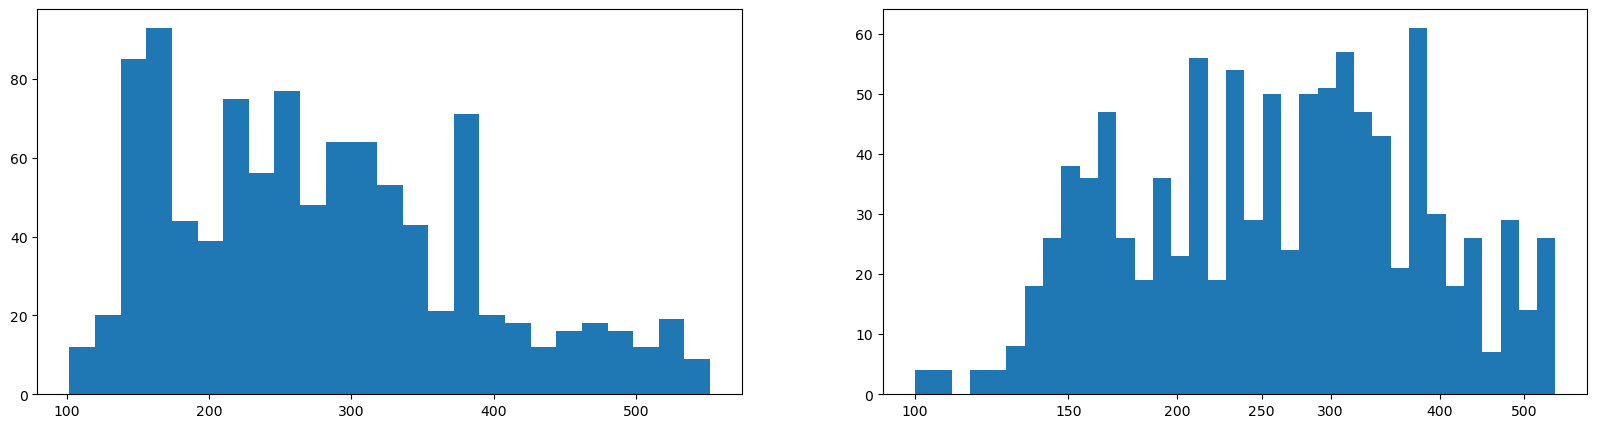

In [16]:
plt.figure(figsize=[20,5])

plt.subplot(1,2,1)
bin_edges = np.arange(102.0,540 +18,18)
plt.hist(data=concrete_clean, x='cement', bins = bin_edges);

plt.subplot(1,2,2)
ticks = [100,150,200,250,300,400,500]
labels = ['{}'.format(v) for v in ticks]
bin_edges = 10**np.arange(2.0,2.73+0.021,0.021)
plt.hist(data=concrete_clean, x='cement', bins = bin_edges)
plt.xscale('log')
plt.xticks(ticks,labels);

#### Observation
The plot initial plot shows a slightly right-skewed with unsual multiple peaks, while the log transform plot shows successive rise and fall in frequency

#### Question:

#### Visualization

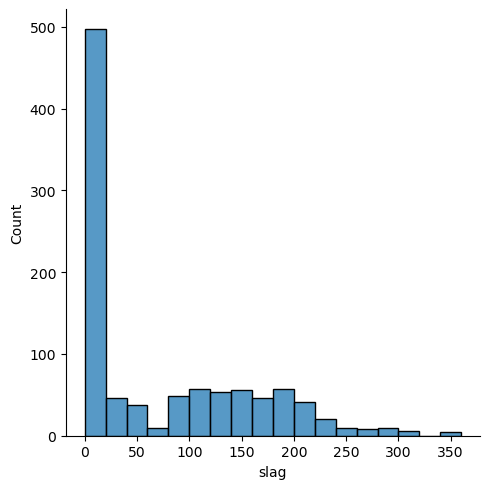

In [17]:
bin_edge = np.arange(concrete_clean['slag'].min(),concrete_clean['slag'].max()+20,20)
sb.displot(concrete_clean['slag'], bins=bin_edge);

#### Observation: 
An extremely tall bar at the zero value which tells that slag is not often used in making concretes.

#### Question:

#### Visualization

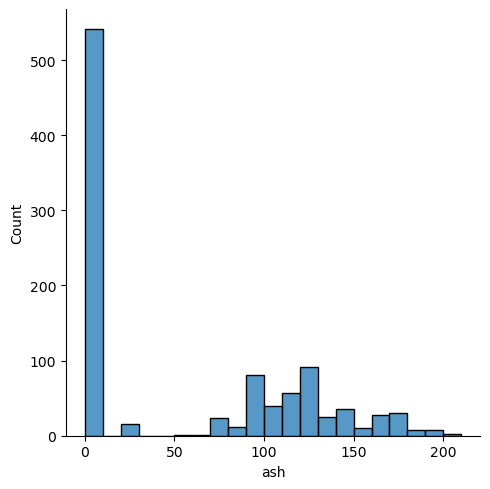

In [18]:
bin_edge = np.arange(concrete_clean['ash'].min(),concrete_clean['ash'].max()+10,10)
sb.displot(concrete_clean['ash'], bins=bin_edge);

#### Observation:
An approximately normal distribution with outliers at the extreme left hand side of the plot - which shows that ash is usually not used when making concretes.

#### Question:

#### Visualization

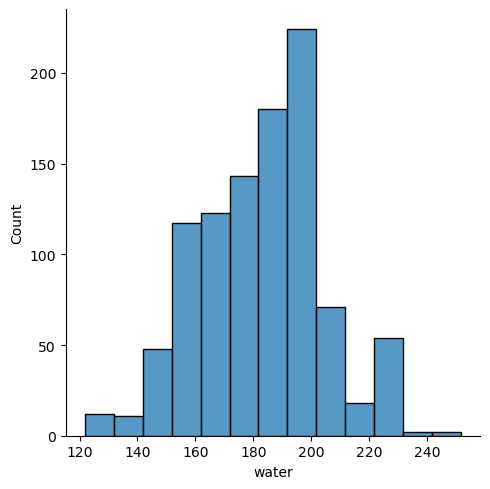

In [19]:
bin_edge = np.arange(concrete_clean['water'].min(),concrete_clean['water'].max()+10,10)
sb.displot(concrete_clean['water'], bins=bin_edge);

#### Observation:
The volumes of water used gives a normally distribution.

#### Question:

#### Visualization

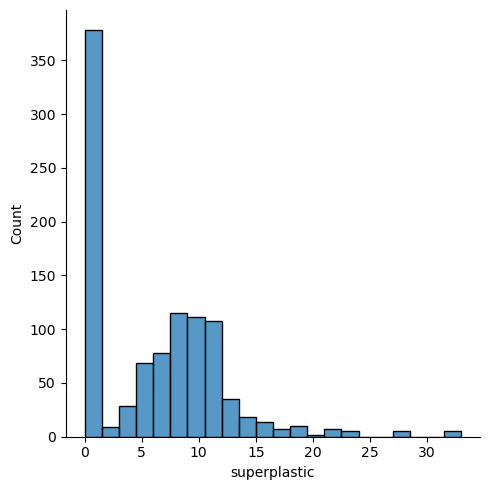

In [20]:
bin_edge = np.arange(concrete_clean['superplastic'].min(),concrete_clean['superplastic'].max()+1.5,1.5)
sb.displot(concrete_clean['superplastic'], bins=bin_edge);

#### Observation: 
This plot also suggest that superplastic, most often than not, is usually not used to make concretes. And its usage gives an approxiamtely normal distribution.

#### Question:

#### Visualization

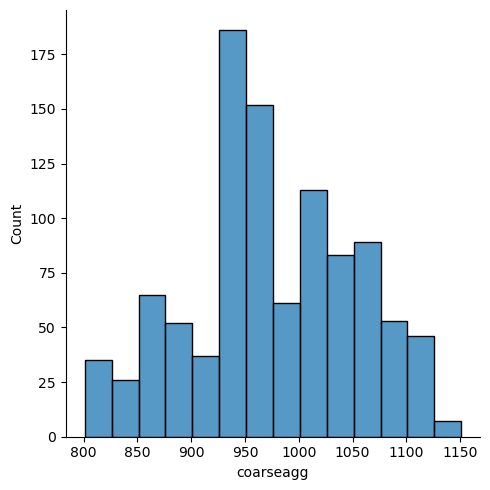

In [21]:
bin_edge = np.arange(concrete_clean['coarseagg'].min(),concrete_clean['coarseagg'].max()+25,25)
sb.displot(concrete_clean['coarseagg'], bins=bin_edge);

#### Observation

#### Question:

#### Visualization

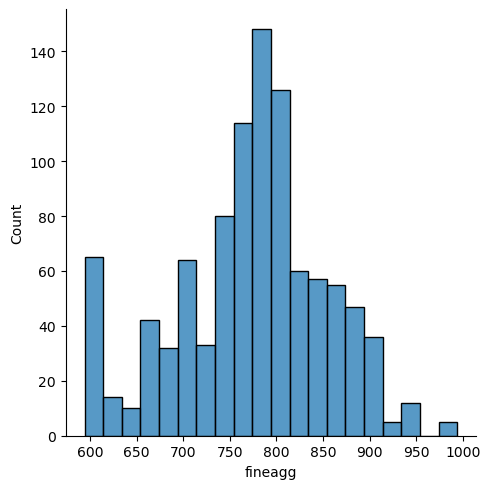

In [22]:
bin_edge = np.arange(concrete_clean['fineagg'].min(),concrete_clean['fineagg'].max()+20,20)
sb.displot(concrete_clean['fineagg'], bins=bin_edge);

#### Observation:

#### Question:

#### Visualization

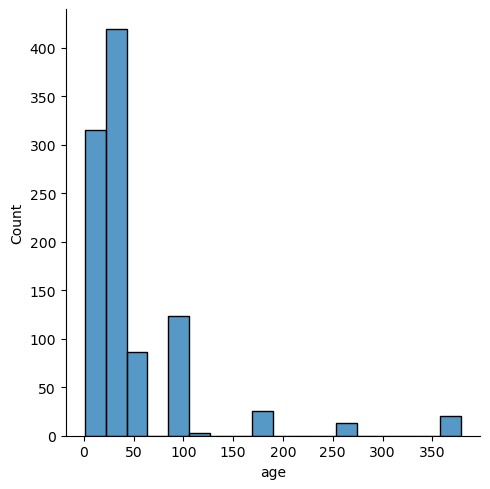

In [23]:
bin_edge = np.arange(concrete_clean['age'].min(),concrete_clean['age'].max()+21,21)
sb.displot(concrete_clean['age'], bins=bin_edge);

#### Observation:
Most concrete mix were left to set in the first 3 weeks,more in the second 3 weeks, followed by the third 3 weeks. Very few mix were left  to set for days greater than 100.

## Bivariate Exploration

#### Question:

#### Visualization

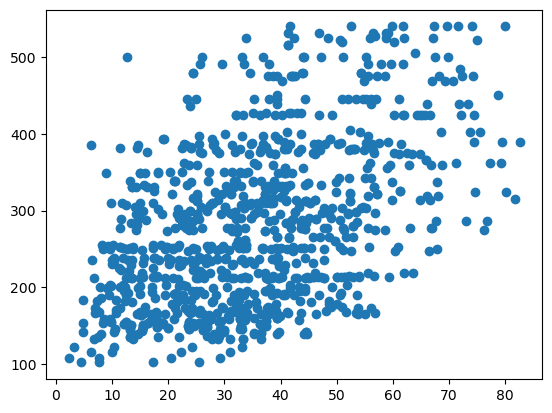

In [27]:
plt.scatter(data=concrete_clean,x='strength',y='cement');

#### Observation:
There is a linear relationship between the amount of cement, and strength of concrete. The higher the cement, the higher the strength of concrete.

#### Question:

#### Visualization

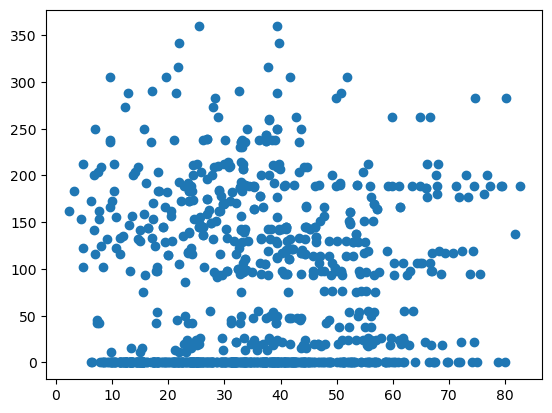

In [28]:
plt.scatter(data=concrete_clean,x='strength',y='slag');

#### Observation:
No relationship is observed.

#### Question:

#### Visualization

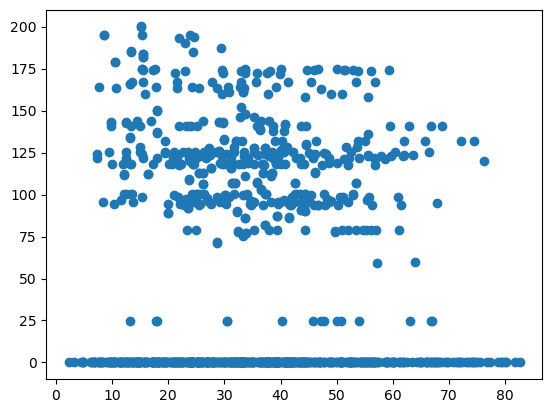

In [29]:
plt.scatter(data=concrete_clean,x='strength',y='ash');

#### Observation:
No meaningful relationship is observed

#### Question:

#### Visualization

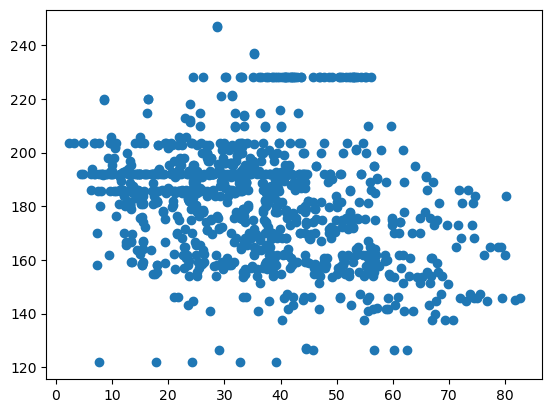

In [30]:
plt.scatter(data=concrete_clean,x='strength',y='water');

#### Observation:
Average water volumes used have more observations falling under low strength (between 10-50), while the lower water volumes(140-160) have more observations in higher strength values (55-80). It seems the lower the water the higher the strength of concrete.

#### Question:

#### Visualization

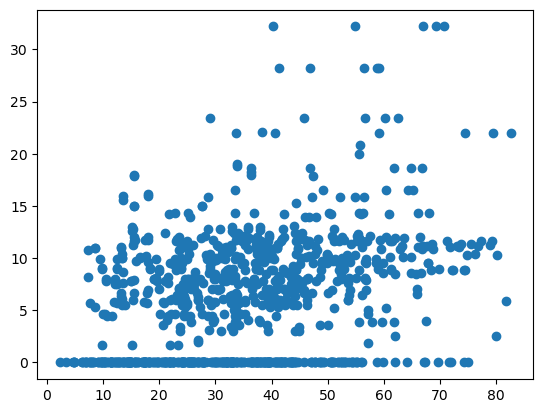

In [31]:
plt.scatter(data=concrete_clean,x='strength',y='superplastic');

#### Observation
No meaningful relationship is observed.